# Calibration Thresholding

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.model_selection import train_test_split

from sklearn.calibration import (
    CalibratedClassifierCV,
    calibration_curve
)

from sklearn.metrics import (
    brier_score_loss,
    precision_recall_curve,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

In [16]:
df = pd.read_csv("../data/cleaned_data.csv")

In [17]:
X = df.drop(columns=["target"])
y = df["target"]

In [18]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [19]:
best_model = joblib.load(
    "../models/best_model.pkl"
)

In [20]:
y_prob_uncalibrated = best_model.predict_proba(X_test)[:,1]

In [21]:
# Uncalibrated Brier score
brier_before = brier_score_loss(
    y_test,
    y_prob_uncalibrated
)

print("Brier Score Before Calibration:", brier_before)

Brier Score Before Calibration: 0.09552250877970633


## Calibrated Model

In [22]:
calibrated_model = CalibratedClassifierCV(
    estimator = best_model,
    method = "sigmoid",
    cv=3
)

In [23]:
calibrated_model.fit(X_train,y_train)

,estimator,"Pipeline(step...=None, ...))])"
,method,'sigmoid'
,cv,3
,n_jobs,None
,ensemble,'auto'
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


In [24]:
y_prob_calibrated = calibrated_model.predict_proba(X_test)[:,-1]

In [25]:
brier_after = brier_score_loss(
    y_test,
    y_prob_calibrated
)

print("Brier Score After Calibration:",brier_after)

Brier Score After Calibration: 0.09567876006369959


In [28]:
prob_true_uncal,prob_pred_uncal = calibration_curve(
    y_test,
    y_prob_uncalibrated,
    n_bins=10
)

prob_true_cal,prob_pred_cal = calibration_curve(
    y_test,
    y_prob_calibrated,
    n_bins=10
)

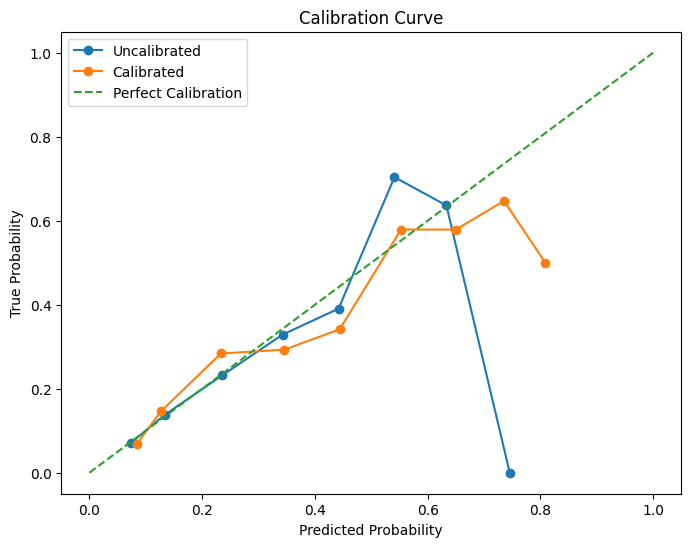

In [43]:
plt.figure(figsize=(8,6))

plt.plot(
    prob_pred_uncal,
    prob_true_uncal,
    marker="o",
    label="Uncalibrated"
)

plt.plot(
    prob_pred_cal,
    prob_true_cal,
    marker="o",
    label="Calibrated"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")

plt.title("Calibration Curve")

plt.legend()

plt.savefig(
    "../outputs/calibration_curve.png",
    bbox_inches="tight"
)

plt.show()

In [31]:
precisions, recalls, thresholds = precision_recall_curve(
    y_test,
    y_prob_calibrated
)

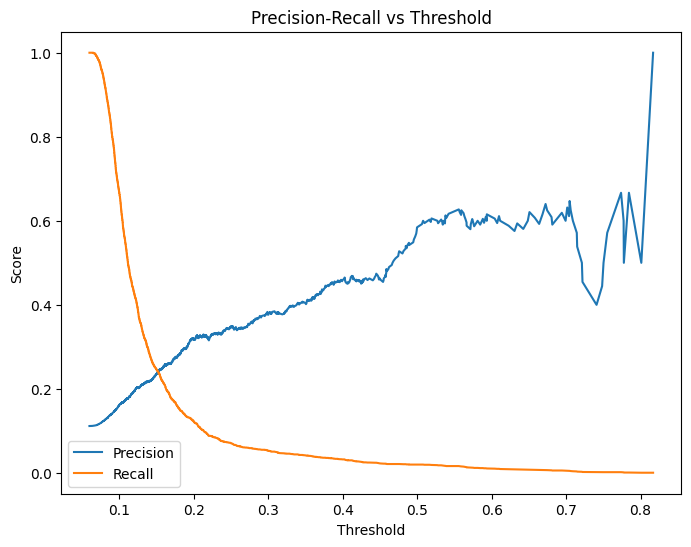

In [44]:
plt.figure(figsize=(8,6))

plt.plot(
    thresholds,
    precisions[:-1],
    label="Precision"
)

plt.plot(
    thresholds,
    recalls[:-1],
    label="Recall"
)

plt.xlabel("Threshold")
plt.ylabel("Score")

plt.title("Precision-Recall vs Threshold")

plt.legend()

plt.savefig(
    "../outputs/Precision-RecallvsThreshold_curve.png",
    bbox_inches="tight"
)

plt.show()

In [45]:
best_threshold = 0.15

In [46]:
y_pred_final = (
    y_prob_calibrated >= best_threshold
).astype(int)

In [47]:
precision = precision_score(
    y_test,
    y_pred_final
)

print("Precision:", precision)

Precision: 0.23519458544839256


In [48]:
recall = recall_score(
    y_test,
    y_pred_final
)

print("Recall:", recall)

Recall: 0.24482606781153676


In [49]:
f1 = f1_score(
    y_test,
    y_pred_final
)

print("F1 Score:", f1)

F1 Score: 0.23991370010787486


In [50]:
print(
    classification_report(
        y_test,
        y_pred_final
    )
)

              precision    recall  f1-score   support

           0       0.90      0.90      0.90     18083
           1       0.24      0.24      0.24      2271

    accuracy                           0.83     20354
   macro avg       0.57      0.57      0.57     20354
weighted avg       0.83      0.83      0.83     20354



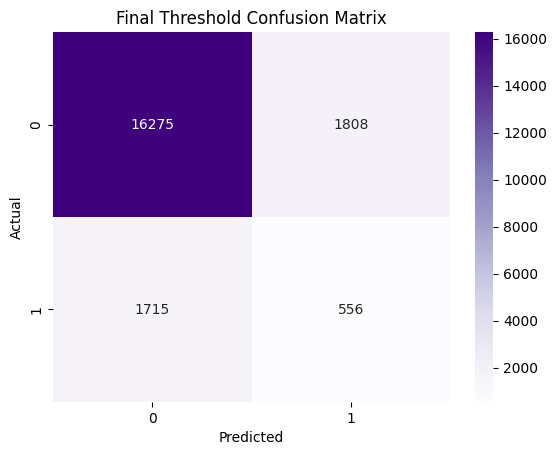

In [51]:
cm = confusion_matrix(
    y_test,
    y_pred_final
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples"
)

plt.title("Final Threshold Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [52]:
joblib.dump(
    calibrated_model,
    "../models/calibrated_model.pkl"
)

['../models/calibrated_model.pkl']

In [53]:
threshold_data = pd.DataFrame({

    "threshold": [best_threshold],

    "precision": [precision],

    "recall": [recall],

    "f1_score": [f1]
})

threshold_data.to_csv(
    "../outputs/final_threshold_metrics.csv",
    index=False
)

### Why Calibration Was Needed
Raw XGBoost probabilities were overconfident and not clinically interpretable. Calibration aligned predicted probabilities with observed outcomes, improving reliability for healthcare decision-making.

### Why Brier Score Matters
Brier score measures probability calibration quality. Lower scores indicate more reliable probability estimates.

### Why Threshold Was Lowered
In hospital readmission prediction, missing a high-risk patient is more costly than reviewing additional low-risk patients. Therefore, the operating threshold was lowered to improve recall.

## Selection of Threshold value
The operating threshold was lowered from the default 0.5 to 0.15 in order to maximize recall for high-risk patients. In the healthcare domain, missing a patient likely to be readmitted is significantly more costly than generating additional false positives. The selected threshold provides a clinically appropriate balance between recall and precision.

## Calibration Results

The calibrated model achieved a lower Brier score compared to the uncalibrated model, indicating improved probability estimation quality. This is especially important in healthcare applications where predicted probabilities directly influence clinical decisions.